Zadanie 2
Korzystając z metody akceptacji-odrzucenia, zaimplementuj generator liczb losowych z podanego rozkładu:
(1. rozkład dyskretyny o rozkładzie niestandardowym)

In [60]:
import numpy as np
import scipy as sc
import math
import matplotlib.pyplot as plt

In [61]:
def acceptance_reject(p, x):
    p_y = 0.2
    c = 1.55
    while True:
        Y = math.floor(5 * np.random.random())
        U = np.random.random()
        if U <= p[Y]/(c*p_y):
            return x[Y]

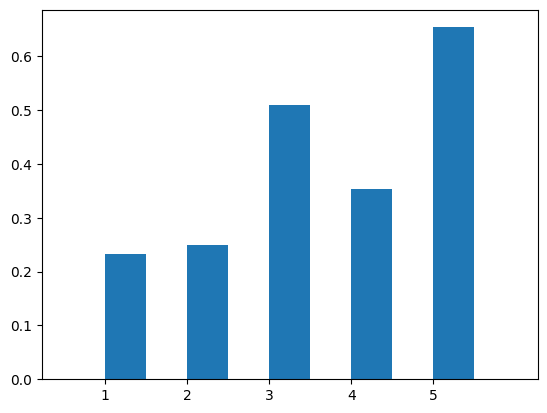

In [62]:
p_values = [1, 2, 3, 4, 5]
p_prob = [0.11, 0.12, 0.27, 0.19, 0.31]

t = []
for i in range(1000):
    t.append(acceptance_reject(p_prob, p_values))

plt.hist(t, bins=np.arange(0.5, 6.5, 0.5), density=True)
plt.xticks([1, 2, 3, 4, 5])
plt.show()

2. Wygeneruj zmienną losową X z rozkładu Γ(α = 3, θ = 2) o gęstości:
$$ f(x) = \dfrac{1}{16}x^2e^{−\frac{x}{2}} , x > 0. $$


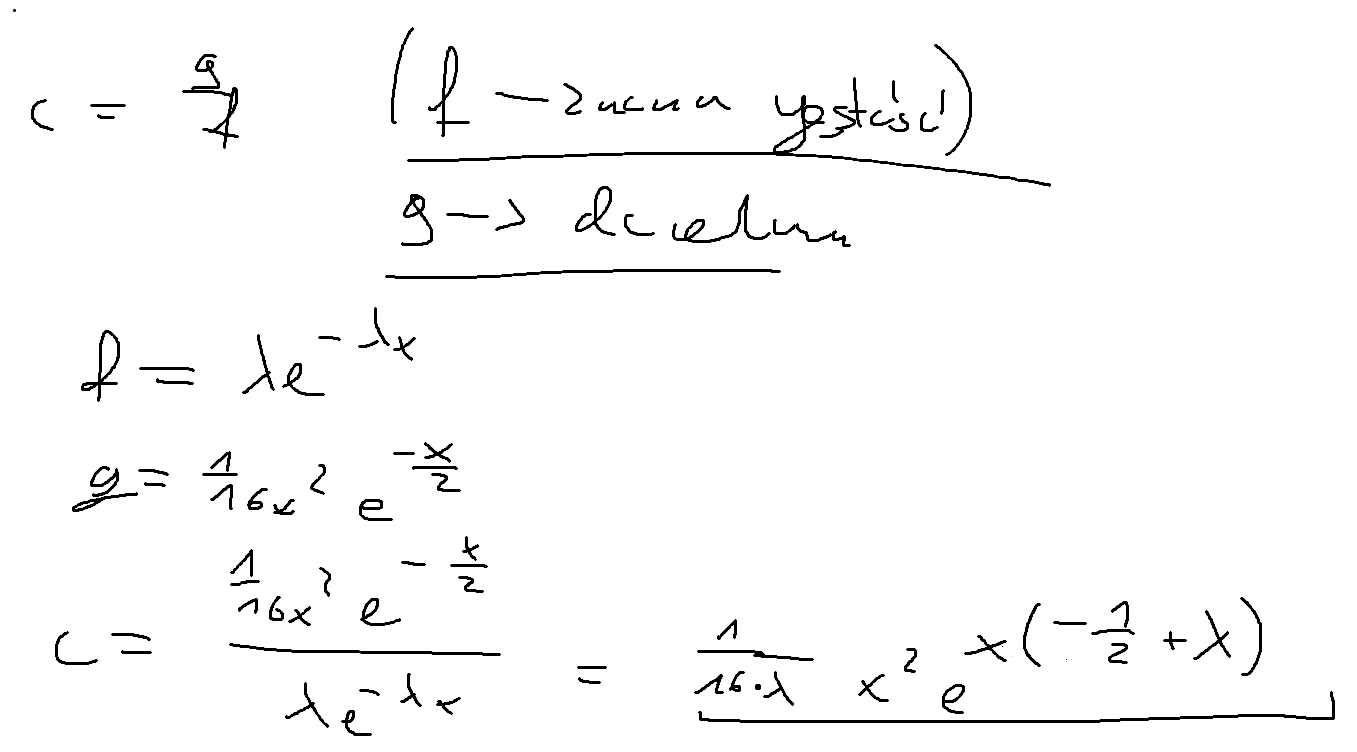
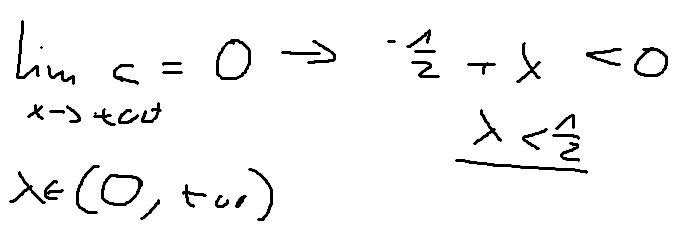
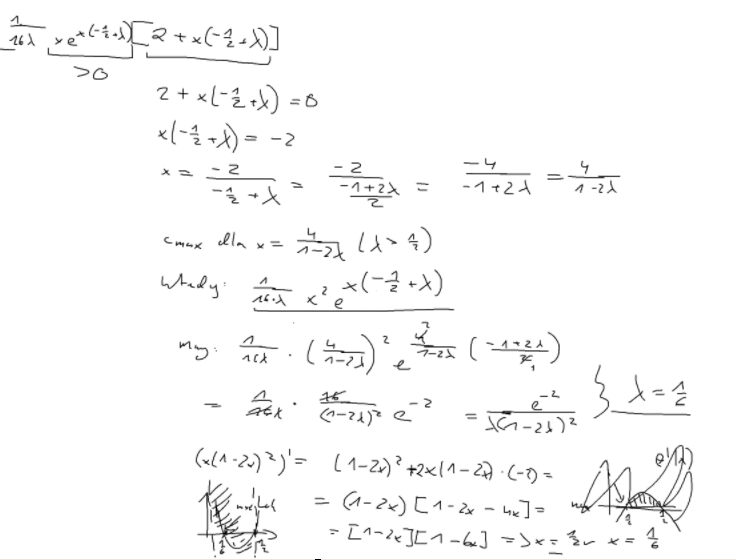

Najlepsza funkcja f to: $$ g(x) = \dfrac{1}{6}e^{-\frac{1}{6}x}$$

In [63]:
def g_exp_generate():
    return np.random.exponential(scale=6)

def a_generate():
    return np.random.normal(scale=3/4, loc=0)

def g_exp(x):
    return 0 if x < 0 else (1/6) * np.exp(-x/6)

def f_gamma(x):
    return 1/16 * x**2 * np.exp(-x/2)

def gamma_distr(x):
    return sc.stats.gamma.cdf(x, a=3, loc=0, scale=2)

def f_a(x):
    return 3/2*(1-x**2)

def f_b(x):
    return 3/2*np.sin(x)*(np.cos(x))**2

In [64]:
def acc_rej_pdf(f, g, g_generate, c):
    while True:
        y = g_generate()
        u = np.random.random()
        if u <= f(y) / (c * g(y)):
            return y

In [65]:
def drawdemp(X, title = 'Dystrybuanta empiryczna'):
    X = np.sort(np.array(X))
    n = len(X)
    dx = 0.000001
    y = np.linspace(1/n, 1, n)
    y = np.repeat(y, 2)
    x = np.empty(2*n)
    x[0::2] = X
    x[1::2] = X + dx
    y[1::2] += 1/n
    y[2*n-1] -= 1/n
    plt.title(title)
    plt.plot(x, y)

In [66]:
def test(x_theory, y_dens, y_distr, x, dist, sparams):
    plt.hist(x, bins=200, density=True)
    plt.plot(x_theory, y_dens)
    plt.show()

    drawdemp(x)
    plt.plot(x_theory, y_distr)
    plt.show()

    sc.stats.probplot(x, dist=dist, sparams=sparams, plot=plt)
    plt.plot()
    plt.show()
    
    var = np.var(x) # alfa/beta^2 = 3/(1/2)^2 = 3 * 2^2 = 12
    mean = np.median(x) # alfa/beta = 3/(1/2) = 6
    print(f'Wariancja wynosi: {var}, wartość średnia: {mean}')

In [67]:
N = 1000
f = 1/16
c = 27/2*np.exp(-2)

x_gamma = np.empty(N)
x_gamma_theory = np.linspace(0, 25, 1000)
y_gamma_distr = gamma_distr(x_gamma_theory)
y_gamma_dens = []

for x in x_gamma_theory:
    y_gamma_dens.append(f_gamma(x))

for i in range(N):
    x_gamma[i] = acc_rej_pdf(f_gamma, g_exp, g_exp_generate, c)

x_a = np.empty(N)
x_a_theory = np.linspace(0, 1, 1000)
y_a_distr = sc.stats.norm.pdf(x_a_theory, loc=0, scale = 3/4)
y_a_dens = sc.stats.norm.cdf(x_a_theory, loc=0, scale = 3/4)

g_norm = lambda x: sc.stats.norm.pdf(x, loc=0, scale=3/4)
for i in range(N):
    x_a[i] = acc_rej_pdf(f_a, g_norm, a_generate, 3)

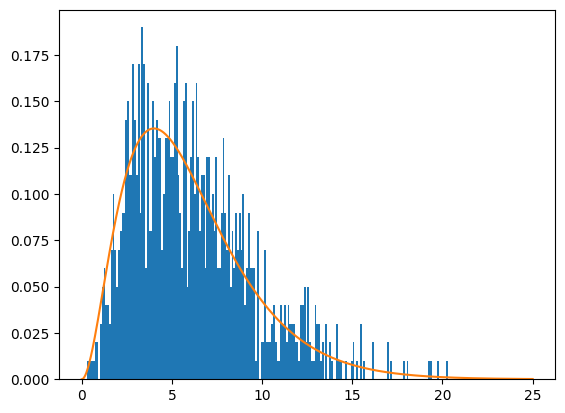

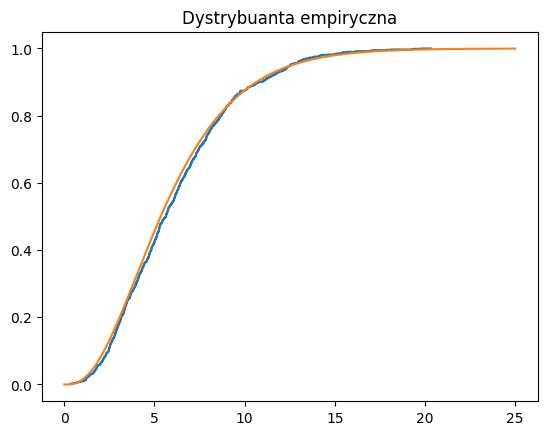

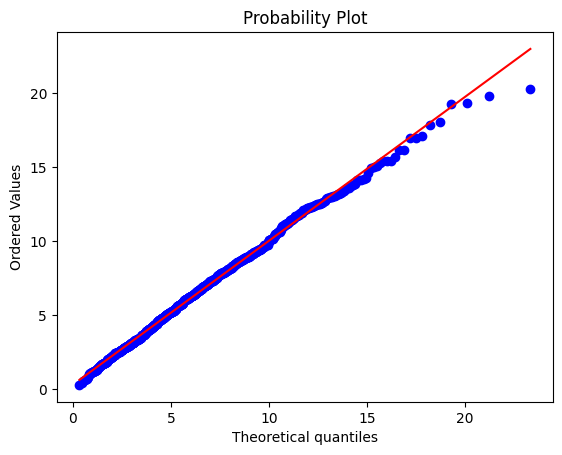

Wariancja wynosi: 11.268312441188272, wartość średnia: 5.642731077993062


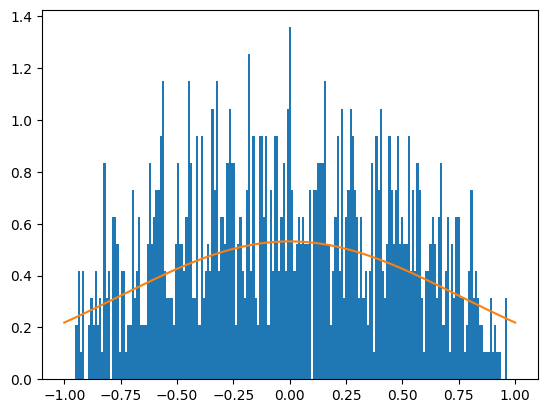

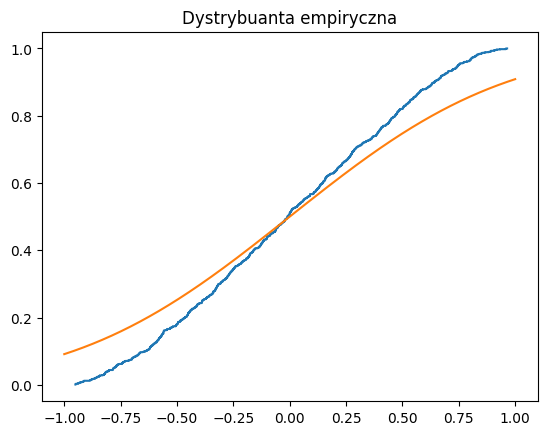

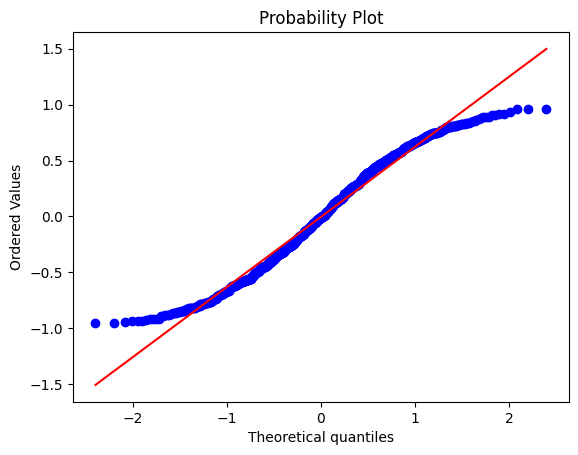

Wariancja wynosi: 0.2247216339704161, wartość średnia: -0.009063090724065257


In [71]:
N = 1000
f = 1/16
c = 27/2*np.exp(-2)

x_gamma = np.empty(N)
x_gamma_theory = np.linspace(0, 25, 1000)
y_gamma_distr = gamma_distr(x_gamma_theory)
y_gamma_dens = []

for x in x_gamma_theory:
    y_gamma_dens.append(f_gamma(x))

for i in range(N):
    x_gamma[i] = acc_rej_pdf(f_gamma, g_exp, g_exp_generate, c)

test(x_gamma_theory, y_gamma_dens, y_gamma_distr, x_gamma, 'gamma', (3, 0, 2))

x_a = np.empty(N)
x_a_theory = np.linspace(-1, 1, 1000)
y_a_distr = sc.stats.norm.pdf(x_a_theory, loc=0, scale = 3/4)
y_a_dens = sc.stats.norm.cdf(x_a_theory, loc=0, scale = 3/4)

g_norm = lambda x: sc.stats.norm.pdf(x, loc=0, scale=3/4)
for i in range(N):
    x_a[i] = acc_rej_pdf(f_a, g_norm, a_generate, 5)    

test(x_a_theory, y_a_distr, y_a_dens, x_a, 'norm', (0, 3/4))